In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import njit
from scipy.stats import norm

1. Construya un DataFrame de pandas con un conjunto de datos lineales simples.

In [4]:
X = np.linspace(3.5267, 5.9876, 20)
Y = 3.4355 + X * (-1.8746)
XY = {"X": X, "Y":Y}
df = pd.DataFrame(XY)

2. Defina una función que calcule la función de coste cuadrática para un modelo de regresión lineal.



In [5]:
def modelo_lineal(theta_0, theta_1, x):
  return theta_0 + theta_1 * x

def funcion_coste_cuadratico(X, Y, modelo, theta_0, theta_1):
    
  Y_modelo = modelo(theta_0, theta_1, X)
  return np.sum((Y_modelo - Y)**2, axis=-1) / 2



3. Fijando inicialmente $\theta_0 = 0$
, evalúe y grafique la función de coste para diferentes valores de $\theta_1$ 
. Determine el valor que minimiza la función de coste y grafique la recta obtenida sobre los datos.

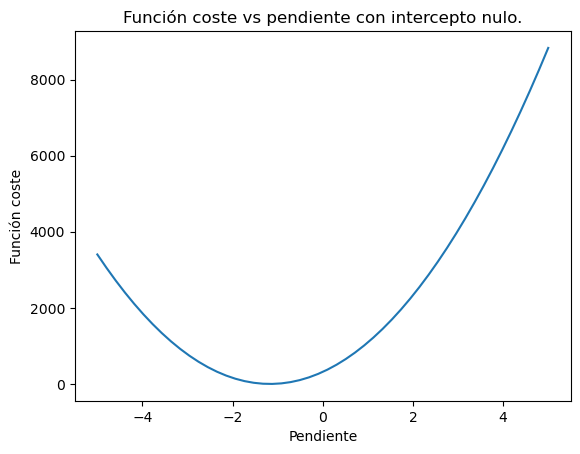

In [6]:
### theta_0 = 0
null_theta_0 = 0

thetas_1 = np.linspace(-5,5,50)
costes = np.array([funcion_coste_cuadratico(X,Y,modelo_lineal,null_theta_0,pendiente) for pendiente in thetas_1])


plt.xlabel('Pendiente')
plt.ylabel('Función coste')
plt.title('Función coste vs pendiente con intercepto nulo.')
plt.plot(thetas_1, costes)
plt.show()

4. Permita ahora que tanto $\theta_0$  como$\theta_1$ 
 varíen. Construya una malla con np.meshgrid, evalúe la función de coste en cada punto y represente su superficie y curvas de nivel.

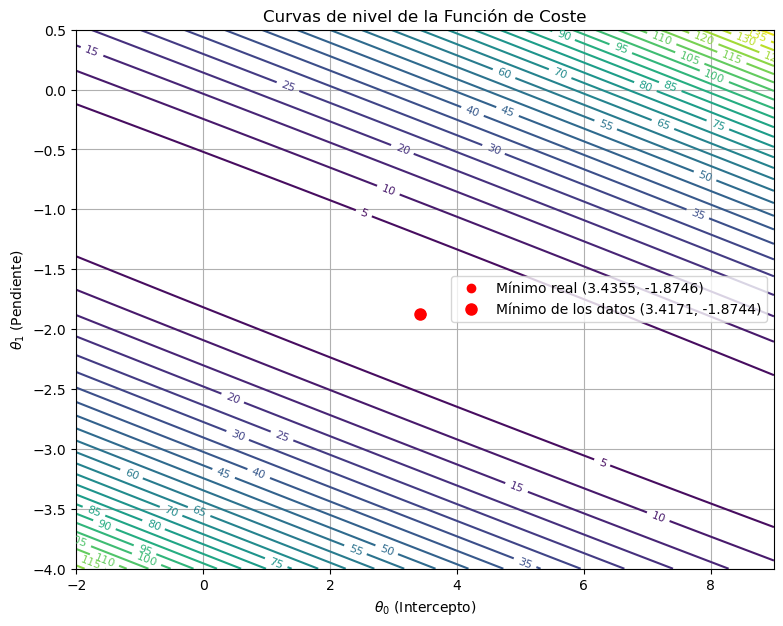

In [7]:
# generacion de datos
X = np.linspace(3.5267, 5.9876, 100)
theta_0_real = 3.4355
theta_1_real = -1.8746

# Y siguiendo recta perfecta
Y = theta_0_real + (theta_1_real * X)

# malla de parámetros ajustada alrededor del mínimo real
THETA_0 = np.linspace(-2, 9, 200)  # Eje X (Intercepto)
THETA_1 = np.linspace(-4, 0.5, 200)  # Eje Y (Pendiente)
TH0, TH1 = np.meshgrid(THETA_0, THETA_1)

# cálculo del coste vectorizado (Broadcasting para evitar bucles for)
# TH0 y TH1 son (200, 200). Añadimos una dimensión para multiplicar por X que es (100,)
Y_pred = TH0[..., np.newaxis] + TH1[..., np.newaxis] * X[np.newaxis, np.newaxis, :]

# calcular el coste (Error Cuadrático Medio / 2) a lo largo del eje de los datos (axis=2)
COSTES = np.mean((Y_pred - Y[np.newaxis, np.newaxis, :])**2, axis=2) / 2

# 4. Generación de la gráfica
plt.figure(figsize=(9, 7))

# Curvas de nivel
contour = plt.contour(TH0, TH1, COSTES, levels=30, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)

# Punto del mínimo real
plt.plot(theta_0_real, theta_1_real, 'ro', markersize=6, 
         label=f'Mínimo real ({theta_0_real}, {theta_1_real})')


# minimo global entre los datos evaluados
i, j = np.unravel_index(np.argmin(COSTES), COSTES.shape)
theta_0_min = TH0[i, j]
theta_1_min = TH1[i, j]
plt.plot(theta_0_min, theta_1_min, 'ro', markersize=8, 
         label=f'Mínimo de los datos ({theta_0_min:.4f}, {theta_1_min:.4f})')

# Etiquetas y formato
plt.xlabel(r'$\theta_0$ (Intercepto)')
plt.ylabel(r'$\theta_1$ (Pendiente)')
plt.title('Curvas de nivel de la Función de Coste')
plt.grid(True)
plt.legend()
plt.show()

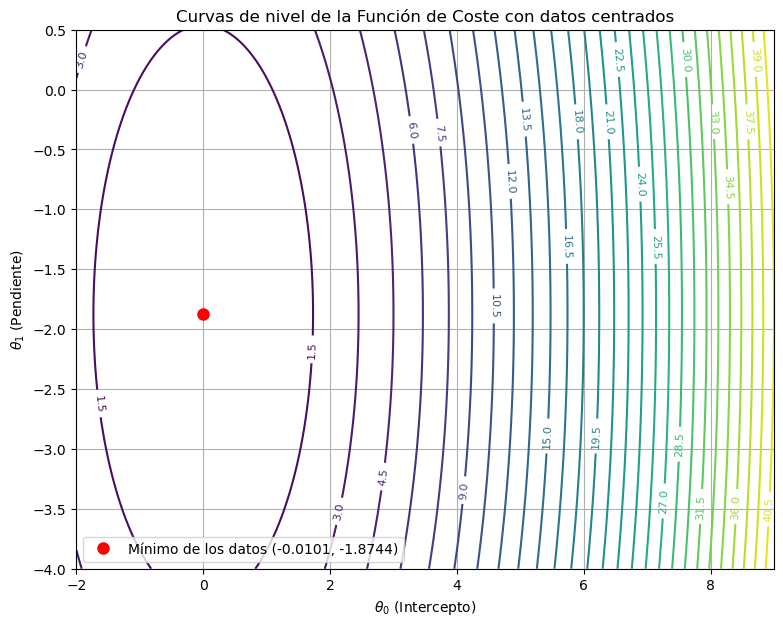

In [8]:
# generacion de datos
X_centrado = X - np.mean(X)
Y_centrado = Y - np.mean(Y)
Y_pred_centrado = TH0[..., np.newaxis] + TH1[..., np.newaxis] * X_centrado[np.newaxis, np.newaxis, :]
# calcular el coste (Error Cuadrático Medio / 2) a lo largo del eje de los datos (axis=2)
COSTES_centrado = np.mean((Y_pred_centrado - Y_centrado[np.newaxis, np.newaxis, :])**2, axis=2) / 2

# generación de la gráfica
plt.figure(figsize=(9, 7))

# curvas de nivel
contour = plt.contour(TH0, TH1, COSTES_centrado, levels=30, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)

# minimo global entre los datos evaluados
i, j = np.unravel_index(np.argmin(COSTES_centrado), COSTES_centrado.shape)
theta_0_min = TH0[i, j]
theta_1_min = TH1[i, j]
plt.plot(theta_0_min, theta_1_min, 'ro', markersize=8, 
         label=f'Mínimo de los datos ({theta_0_min:.4f}, {theta_1_min:.4f})')


plt.xlabel(r'$\theta_0$ (Intercepto)')
plt.ylabel(r'$\theta_1$ (Pendiente)')
plt.title('Curvas de nivel de la Función de Coste con datos centrados')
plt.grid(True)
plt.legend()
plt.show()

5. Interprete geométricamente la forma de la función de coste e identifique el mínimo global.
Las curvas de nivel de la función de coste en función de los parámetros de ajuste son elipses, lo cual se debe a que la expresión $\sum_i (\theta_1 X_i + \theta_0 - Y_i)^2$ es una forma cuadrática en $\theta_0$ y $\theta_1$. El largo de los semiejes en cada eje da información de qué tanto afecta la variación de un parámetro de ajuste sobre el otro. Por ejemplo, cuando los datos no estaban centrados, la influencia de $\theta_0$ en $theta_1$ era mucho mayor que al centrarlo.

6. Repita el procedimiento para un conjunto de datos con ruido y compare los resultados con el caso ideal.

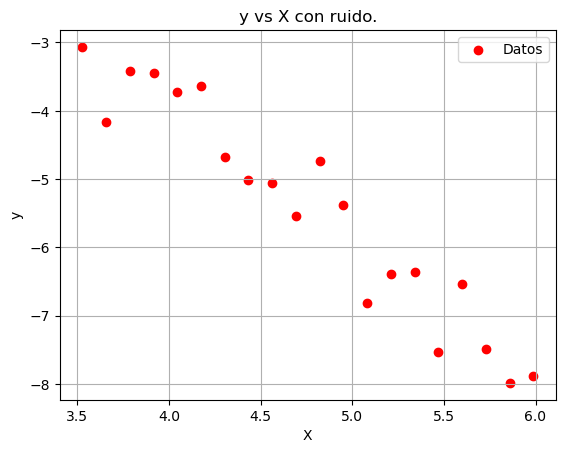

In [9]:
# datos originales
X = np.linspace(3.5267, 5.9876, 20)
theta_0_real = 3.4355
theta_1_real = -1.8746

# sumar ruido a Y
ruido = norm.rvs(loc=0, scale=0.4, size=X.shape, random_state = 17)
Y = theta_0_real + (theta_1_real * X) + ruido

plt.scatter(X, Y, c = "red", label = 'Datos')
plt.xlabel('X')
plt.ylabel('y')
plt.title('y vs X con ruido.')
plt.grid()
plt.legend()

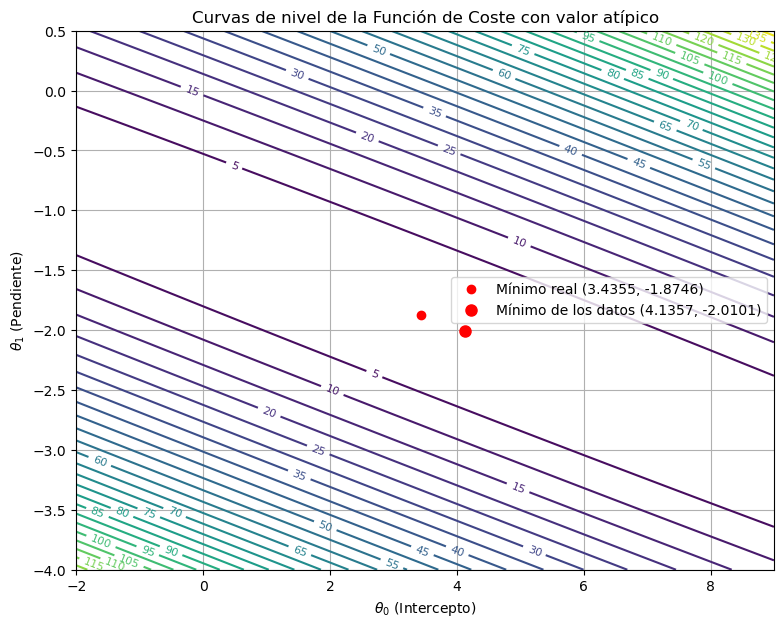

In [10]:
# malla de parámetros ajustada alrededor del mínimo real
THETA_0 = np.linspace(-2, 9, 200)  # Eje X (Intercepto)
THETA_1 = np.linspace(-4, 0.5, 200)  # Eje Y (Pendiente)
TH0, TH1 = np.meshgrid(THETA_0, THETA_1)

# cálculo del coste vectorizado (Broadcasting para evitar bucles for)
Y_pred = TH0[..., np.newaxis] + TH1[..., np.newaxis] * X[np.newaxis, np.newaxis, :]

# calcular el coste (Error Cuadrático Medio / 2) a lo largo del eje de los datos (axis=2)
COSTES = np.mean((Y_pred - Y[np.newaxis, np.newaxis, :])**2, axis=2) / 2

# generación de la gráfica
plt.figure(figsize=(9, 7))

# Curvas de nivel
contour = plt.contour(TH0, TH1, COSTES, levels=30, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)

# Punto del mínimo real
plt.plot(theta_0_real, theta_1_real, 'ro', markersize=6, 
         label=f'Mínimo real ({theta_0_real}, {theta_1_real})')


# minimo global entre los datos evaluados
i, j = np.unravel_index(np.argmin(COSTES), COSTES.shape)
theta_0_min = TH0[i, j]
theta_1_min = TH1[i, j]
plt.plot(theta_0_min, theta_1_min, 'ro', markersize=8, 
         label=f'Mínimo de los datos ({theta_0_min:.4f}, {theta_1_min:.4f})')


# Etiquetas y formato
plt.xlabel(r'$\theta_0$ (Intercepto)')
plt.ylabel(r'$\theta_1$ (Pendiente)')
plt.title('Curvas de nivel de la Función de Coste con valor atípico')
plt.grid(True)
plt.legend()
plt.show()

7.Analice el efecto de introducir un valor atípico en el conjunto de datos. Discuta cómo cambia la solución y qué limitaciones presenta la función de coste cuadrática.

In [12]:
# datos originales
X = np.linspace(3.5267, 5.9876, 20)
theta_0_real = 3.4355
theta_1_real = -1.8746

# sumar ruido a Y
ruido = norm.rvs(loc=0, scale=0.4, size=X.shape, random_state = 17)
Y = theta_0_real + (theta_1_real * X) + ruido

# introducir valor atípico
Y[12] = -67 

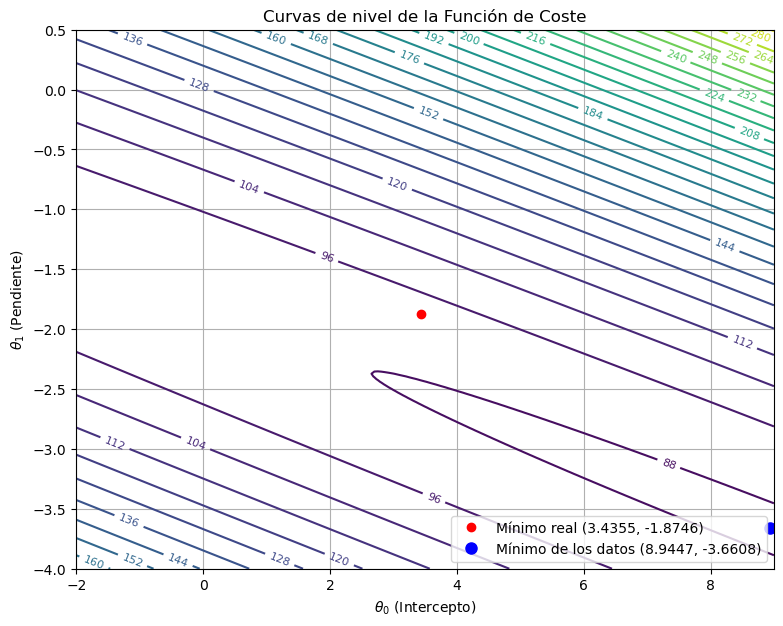

In [14]:
# malla de parámetros ajustada alrededor del mínimo real
THETA_0 = np.linspace(-2, 9, 200)  # Eje X (Intercepto)
THETA_1 = np.linspace(-4, 0.5, 200)  # Eje Y (Pendiente)
TH0, TH1 = np.meshgrid(THETA_0, THETA_1)

# cálculo del coste vectorizado (Broadcasting para evitar bucles for)
Y_pred = TH0[..., np.newaxis] + TH1[..., np.newaxis] * X[np.newaxis, np.newaxis, :]

# calcular el coste (Error Cuadrático Medio / 2) a lo largo del eje de los datos (axis=2)
COSTES = np.mean((Y_pred - Y[np.newaxis, np.newaxis, :])**2, axis=2) / 2

# generación de la gráfica
plt.figure(figsize=(9, 7))

# Curvas de nivel
contour = plt.contour(TH0, TH1, COSTES, levels=30, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)

# Punto del mínimo real
plt.plot(theta_0_real, theta_1_real, 'ro', markersize=6, 
         label=f'Mínimo real ({theta_0_real}, {theta_1_real})')


# minimo global entre los datos evaluados
i, j = np.unravel_index(np.argmin(COSTES), COSTES.shape)
theta_0_min = TH0[i, j]
theta_1_min = TH1[i, j]
plt.plot(theta_0_min, theta_1_min, 'bo', markersize=8, 
         label=f'Mínimo de los datos ({theta_0_min:.4f}, {theta_1_min:.4f})')


plt.xlabel(r'$\theta_0$ (Intercepto)')
plt.ylabel(r'$\theta_1$ (Pendiente)')
plt.title('Curvas de nivel de la Función de Coste')
plt.grid(True)
plt.legend()
plt.show()

Los datos atípicos adquieren demasiado peso, introduciendo un error para nada despreciable en la función de coste.

8. Compare el ajuste obtenido con un modelo lineal sobre un conjunto de datos no lineales. Discuta si minimizar la función de coste garantiza que el modelo sea adecuado.

$$ y'(x) = 5 \sin \left(0.5 x \right) - 8.4 $$

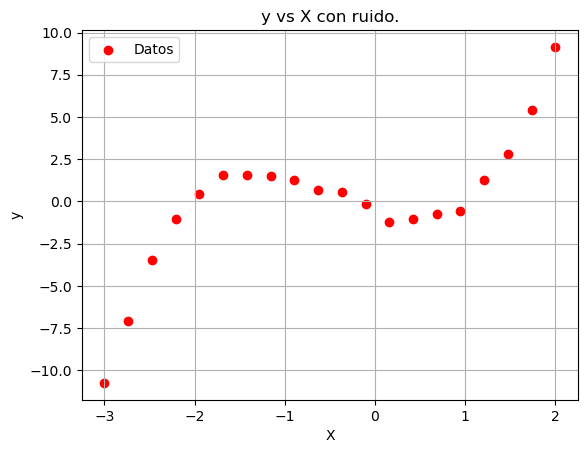

In [15]:
# datos originales
X = np.linspace(-3, 2, 20)

# sumar ruido a Y
ruido = norm.rvs(loc=0, scale=0.2, size=X.shape, random_state = 17)
Y = (X-1)*(X+0.3)*(X+2) + ruido
plt.scatter(X, Y, c = "red", label = 'Datos')
plt.xlabel('X')
plt.ylabel('y')
plt.title('y vs X con ruido.')
plt.grid()
plt.legend()

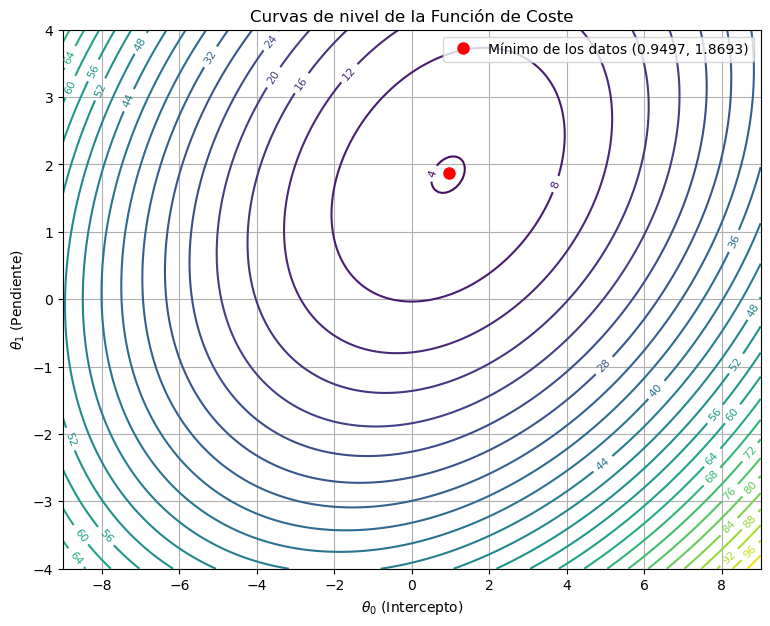

In [16]:
# malla de parámetros ajustada alrededor del mínimo real
THETA_0 = np.linspace(-9, 9, 200)  # Eje X (Intercepto)
THETA_1 = np.linspace(-4, 4, 200)  # Eje Y (Pendiente)
TH0, TH1 = np.meshgrid(THETA_0, THETA_1)

# cálculo del coste vectorizado (Broadcasting para evitar bucles for)
Y_pred = TH0[..., np.newaxis] + TH1[..., np.newaxis] * X[np.newaxis, np.newaxis, :]

# calcular el coste (Error Cuadrático Medio / 2) a lo largo del eje de los datos (axis=2)
COSTES = np.mean((Y_pred - Y[np.newaxis, np.newaxis, :])**2, axis=2) / 2

# generación de la gráfica
plt.figure(figsize=(9, 7))

# Curvas de nivel
contour = plt.contour(TH0, TH1, COSTES, levels=30, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)



# minimo global entre los datos evaluados
i, j = np.unravel_index(np.argmin(COSTES), COSTES.shape)
theta_0_min = TH0[i, j]
theta_1_min = TH1[i, j]
plt.plot(theta_0_min, theta_1_min, 'ro', markersize=8, 
         label=f'Mínimo de los datos ({theta_0_min:.4f}, {theta_1_min:.4f})')


plt.xlabel(r'$\theta_0$ (Intercepto)')
plt.ylabel(r'$\theta_1$ (Pendiente)')
plt.title('Curvas de nivel de la Función de Coste')
plt.grid(True)
plt.legend()
plt.show()

Sea cual sea el modelo, la minimización de la función de coste por sí sola no da idea de cuán adecuado sea el modelo, pues entre otras cosas, no es posible asegurar que el modelo se generalice adecuadamente a los datos más allá del rango de muestreado, por ejemplo.

9. Obtenga la expresión teórica de la función de coste en el caso con un parámetro y con dos parámetros, e interprete el significado de sus mínimos.

Para un parámetro, la función de coste es una parábola, por lo que su minímo es el punto donde ésta está centrada.

$$
2m J(\theta_1) = \sum_{i} (m X_i - Y_i)^2 = \theta_1^2 \left( \sum_i X_i^2 \right) - 2 \theta_1 \left( \sum_i X_i Y_i \right) + \left( \sum_i Y_i^2 \right)
$$

que al completar cuadrados,

$$
2m J(\theta_1) = \left( \theta_1 \sqrt{ \sum_i X_i^2 } - \frac{\sum_i X_i Y_i }{\sqrt{ \sum_i X_i^2 }} \right) - \left( \frac{\sum_i X_i Y_i }{\sqrt{ \sum_i X_i^2 }} \right)^2 +  \left( \sum_i Y_i^2 \right)
$$

de modo que el mínimo dados estos datos sería $$\theta_1 = \frac{\sum_i X_i Y_i }{ \sum_i X_i^2 }$$


En dos variables, la función de costo cuadrático es

$$
2mJ(\theta) = \theta_1^2 \left(\sum_i X_i^2 \right) + \theta_0^2 N + 2 \theta_0 \theta_1 \left(\sum_i X_i \right) -2 \theta_1 \left(\sum_i X_I Y_i \right) - 2 \theta \left( \sum_i Y_i\right) + \sum_i Y_i^2 
$$
siendo $N$ el número de datos. Esta función de costo define una familia de elipses, que tienen por centro al mínimo de la función coste, el cual de igual modo se encuentra completando cuadrados, siendo el término cruzado en los parámetros debido a que la familia de elipses está rotada.

10. Construya el algoritmo de gradiente descendiente. Pruébelo con tres valores distintos de $\alpha$ para encontrar el mínimo de $f(x) = (x-4)^2$.

In [29]:
def gradescendiente_1d(r_0, f, lr, h, tol):
    r_1 = r_0
    r_delta = r_1 + h
    r_2 = r_1 - lr * (f(r_delta) - f(r_0))/h
    while abs(r_2 - r_1) > tol:
        r_0 = r_1
        r_delta = r_1 + h
        r_1 = r_2
        r_2 = r_1 - lr * (f(r_delta) - f(r_0))/h
    return r_2
        

In [30]:
f = lambda x: (x-4)**2


In [33]:
print('alpha = 0.1', 'minimo = ', gradescendiente_1d(1, f, 0.1, 1e-5, 1e-10))
print('alpha = 0.01', 'minimo = ', gradescendiente_1d(1, f, 0.01, 1e-5, 1e-10))
print('alpha = 0.001', 'minimo = ', gradescendiente_1d(1, f, 0.001, 1e-5, 1e-10))

alpha = 0.1 minimo =  3.9999949998053284
alpha = 0.01 minimo =  3.9999949952151
alpha = 0.001 minimo =  3.999994950297506


alpha mas pequeño ralentiza la convergencia.

11. Encontrar el mínimo de la siguiente función a través del método del gradiente descendente:
$$F(x,y) = \sin \left( \frac{1}{2} x^2 - \frac{1}{4}y^2+3 \right) \cos(2x+1-e^y)$$

Para ello, realice una gráfica de la función en 3D y un mapa de contorno de la función.
Determine el valor mínimo de la función con el método del gradiente descendente.)

In [59]:
F = lambda x, y: np.sin(x**2 / 2 - y**2 / 4 + 3) * np.cos(2*x + 1 - np.exp(y))

In [5]:
def gradiente_numerico_2d(r, f, h):
    gradiente = np.empty(2)
    for i in range(2):
        r_delta = r.copy()
        r_delta[i] += h
        gradiente[i] = (f(r_delta[0], r_delta[1]) - f(r[0], r[1])) / h
    return gradiente


def gradescendiente_2d(r_0, f, lr, h, tol, pasos_max):
    r_1 = np.asarray(r_0, dtype=float).copy()
    trayectoria = []
    for _ in range(pasos_max):
        r_2 = r_1 - lr * gradiente_numerico_2d(r_1, f, h)
        trayectoria.append(r_1.copy())
        if np.linalg.norm(r_2 - r_1) <= tol:
            return r_2, trayectoria
        r_1 = r_2
    raise RuntimeError("El descenso no convergio dentro de max_iter")


Locator attempting to generate 2001 ticks ([-1.0, ..., 1.0]), which exceeds Locator.MAXTICKS (1000).


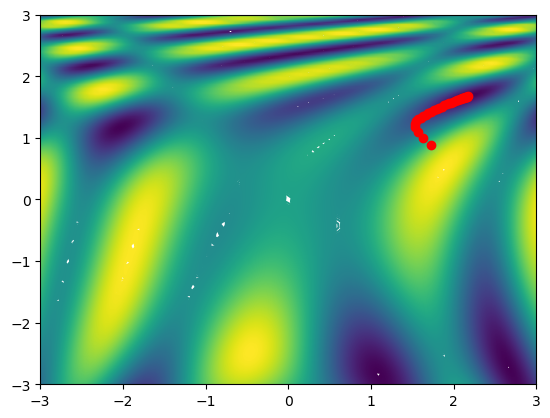

In [112]:

a=3
r_0 = np.random.rand(2)*2*a-a  # Punto inicial aleatorio en el rango [-10, 10]
#r_0 = np.array([-2, 2])  # Punto inicial aleatorio en el rango [-10, 10]
minimo, trayectoria = gradescendiente_2d(r_0, F, lr=0.01, h=1e-5, tol=1e-3, pasos_max=100000)

x = np.linspace(-a, a, 100)
y = np.linspace(-a, a, 100)
X, Y = np.meshgrid(x, y)
plt.contour(X, Y, F(X, Y), levels=2000, cmap = 'viridis')

for p in trayectoria[::5]:
    plt.plot(p[0], p[1], 'ro')




12. Empleando los siguientes datos:

In [18]:
X = np.linspace(0, 1, 100)
y = 0.2 + 0.2*X + 0.02*np.random.random(100)

y las herramientas desarrolladas en los apartados anteriores, construya un algorítmo que permita determinar una regresión lineal.

In [26]:
def regresion_lineal(X, y, tol):
    f_coste = lambda theta_0, theta_1: np.sum((theta_0 + theta_1 * X - y)**2) / 2
    r_0 = np.random.rand(2)  # Punto inicial aleatorio
    lr = 0.001  # Tasa de aprendizaje
    h = 1e-5  # Paso para el gradiente numérico
    tol = 1e-5  # Tolerancia para la convergencia
    pasos_max = 10000  # Número máximo de pasos
    Theta, _ = gradescendiente_2d(r_0, f_coste, lr, h, tol, pasos_max)
    return Theta


In [27]:
b, m = regresion_lineal(X,y,1e-17)
print('Solución propia.')
print(f"Pendiente (m): {m:.6f}")
print(f"Intersección (b): {b:.6f}")

Solución propia.
Pendiente (m): 0.199646
Intersección (b): 0.210425


13. Compare su resultado empleando la libreria linearRegresion() de sklearn.

In [28]:
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()
X_re = X.reshape(-1,1)
modelo.fit(X_re, y)
m_skl = modelo.coef_          # Pendiente
b_skl = modelo.intercept_     # Intercepto
print('Solución de sklearn.')
print(f"Pendiente (m): {m_skl[0]:.6f}")
print(f"Intersección (b): {b_skl:.6f}")

Solución de sklearn.
Pendiente (m): 0.200936
Intersección (b): 0.209739


Ambas soluciones no se alejan mucho uno de la otra.

14. (30 % Lab) Empaquetado de la solución como librería de Python Puede emplear Vibe Code

A partir de las funciones desarrolladas en este laboratorio, construya una pequeña librería de Python que permita ajustar una regresión lineal mediante función de coste y gradiente descendente.

La librería debe incluir:

1. Una función para calcular la hipótesis lineal.
2. Una función para calcular la función de coste.
3. Una función para ejecutar el gradiente descendente.
4. Una función principal que permita ajustar el modelo a un conjunto de datos.
5. Documentación básica de cada función.
6. Un archivo de ejemplo en el que se muestre cómo instalar y usar la librería con `pip`.

Como resultado final, el estudiante debe entregar:

* El código fuente organizado como paquete de Python.
* Un archivo `README.md` con instrucciones de instalación.
* La documentación de uso de la librería.
* Un ejemplo de ejecución sobre los datos del laboratorio. del laboratorio.

## 14. Empaquetado de la solución como librería de Python

La solución se organizó como el paquete `lineareg`, ubicado en la carpeta `lineareg/`. El paquete solo utiliza `numpy`: el gradiente se calcula directamente a partir de la expresión analítica de la función de coste, sin `scipy`, `sklearn` ni otras librerías.

**Archivos entregables:**

- `lineareg/modelo.py`: hipótesis lineal, función de coste, descenso gradiente y función principal `ajustar_modelo`.
- `lineareg/__init__.py`: API pública de la librería.
- `pyproject.toml`: configuración para instalar el paquete con `pip`.
- `README.md`: documentación básica, instalación y uso.
- `examples/ejemplo_lab4.py`: ejemplo reproducible con los datos de este laboratorio.

Para instalar la librería desde la carpeta raíz del laboratorio:

```bash
python -m pip install -e .
```

Después puede ejecutarse el ejemplo con:

```bash
python examples/ejemplo_lab4.py
```

La función `ajustar_modelo(X, y)` retorna un diccionario con el intercepto, la pendiente, el vector `theta` y el historial de la función de coste.

In [3]:
import numpy as np
from lineareg import ajustar_modelo, coste, hipotesis_lineal

# Datos del laboratorio
X_lab = np.linspace(0, 1, 100)
y_lab = 0.2 + 0.2 * X_lab + 0.02 * np.random.default_rng(17).random(100)

modelo_lineareg = ajustar_modelo(
    X_lab,
    y_lab,
    tasa_aprendizaje=0.1,
    tolerancia=1e-12,
)

print(f"Intercepto: {modelo_lineareg['intercepto']:.6f}")
print(f"Pendiente: {modelo_lineareg['pendiente']:.6f}")
print(f"Coste inicial: {modelo_lineareg['historial_coste'][0]:.8f}")
print(f"Coste final: {modelo_lineareg['historial_coste'][-1]:.8f}")
print(f"Predicción para X=0.5: {hipotesis_lineal(0.5, modelo_lineareg['theta']):.6f}")

assert modelo_lineareg['historial_coste'][-1] < modelo_lineareg['historial_coste'][0]
assert np.isclose(
    coste(X_lab, y_lab, modelo_lineareg['theta']),
    modelo_lineareg['historial_coste'][-1],
)
print("La librería fue importada y probada correctamente.")

Intercepto: 0.208854
Pendiente: 0.200929
Coste inicial: 0.04956881
Coste final: 0.00001378
Predicción para X=0.5: 0.309318
La librería fue importada y probada correctamente.
